In [111]:
import re
with open("nalgae.txt", "r", encoding="utf-8") as f:
    text = f.read().replace(" ", "_")
text = re.sub(r'[^0-9가-힣.,!?_()\n]', ' ', text)
# text = re.sub(r'\s+', ' ', text)

len(text)

21445

In [112]:
len(text)/len(set(text))

26.907151819322458

In [121]:
bag_of_word = list(set(text))
itos = {i:s for i, s in enumerate(bag_of_word)}
stoi = {s:i for i, s in enumerate(bag_of_word)} 
total_tokens = len(bag_of_word)
itos[stoi["안"]]

'안'

In [122]:
def make_chunks(data, n=5):
    for ptr in range(0, len(data)-n-1):
        yield data[ptr:ptr+n+1]

n = 3
chunks = [chunk for chunk in make_chunks(text, 3)]

In [123]:
chunks[10:13]

['제가_되', '가_되어', '_되어_']

In [124]:
len(chunks)

21441

In [125]:
def tokenize(chunk):
    return [stoi[char] for char in chunk]

def stringfy(tokens):
    return "".join([itos[token] for token in tokens])

print("Tokens:", tokenize(chunks[0]))
print("String:", stringfy(tokenize(chunks[0])))

Tokens: [643, 746, 795, 795]
String: 날개




In [126]:
import math
print("Total tokens:", len(stoi))
print("Current Entropy:", math.log2(len(stoi)))

Total tokens: 797
Current Entropy: 9.638435913990472


In [127]:
import random

def beautiful_f(x):
    return random.randint(0, total_tokens)

def generate(x, function, max_length=100):
    for i in range(len(x), max_length):
        x += stringfy([function(x[i-n:i])])
    return x

chunk = chunks[0]
x = chunk[:n]
y = chunk[n]
print(generate(x, beautiful_f))

날개
봉께왜집쿵하새훨형냐며덩못운젊코쾌뜰넷럽막듣면센너퍼뚜콱릿냐막싶페흘꽥싸툭조
람많멩찌복써써커제림뻔졌랴문옜낼쏘앞닿띄칸뜸런끔들뜨왔튼룩떡논알용털지잉세센찮깐큼줄릴듯색엿느겸1만_덟래랴걱엎씬뚜


# 오차 역전파에 대해서 알아보자.

$y=Ax+B$: x: 길이 2 벡터 / y: 길이 3 벡터 

$A \in \mathbb{R^{32}}, B \in \mathbb{R^3}$

$\frac{\partial{y}}{\partial{A}}$, $\frac{\partial{y}}{\partial{B}}$는 무엇일까?

$\frac{\partial{y}_i}{\partial{A}}$

In [128]:
import torch
w1_torch = torch.randn(3, 2, requires_grad=True)
b1_torch = torch.randn(3, requires_grad=True)
x_torch = torch.randn(2, requires_grad=True)
y = w1_torch @ x_torch + b1_torch
loss = y.sum()
loss.backward()
print("w1:",w1_torch.grad)
print("b1:",b1_torch.grad)
print("x:",x_torch.grad)

w1: tensor([[-0.2792,  0.9554],
        [-0.2792,  0.9554],
        [-0.2792,  0.9554]])
b1: tensor([1., 1., 1.])
x: tensor([-2.3798, -3.0099])


In [129]:
import numpy as np

x = x_torch.detach().numpy()
W1 = w1_torch.detach().numpy()
B1 = b1_torch.detach().numpy()
y = W1 @ x + B1

In [130]:
dydW1 = np.stack([x, x, x], axis=0)
dydB1 = np.ones(3)
dydX = np.sum(W1, axis=0)
print("w1:",dydW1)
print("b1:",dydB1)
print("x:",dydX)

w1: [[-0.279168  0.955416]
 [-0.279168  0.955416]
 [-0.279168  0.955416]]
b1: [1. 1. 1.]
x: [-2.3797526 -3.0099313]


In [131]:
import numpy as np

W = np.random.randn(1, n) / 100
B = np.zeros((1))

losses = []
for _ in range(100):
    chunk = random.choice(chunks)
    ground_truth = tokenize(chunk)[n] / total_tokens
    x = np.array(tokenize(chunk)[:n]) / total_tokens
    print(chunk)

    y = W @ x + B
    error = np.sum((y-ground_truth) ** 2)
    print("Error:", error)
    losses.append(error)

    dydW = np.tile(x, (W.shape[0], 1)) 
    dydB = np.ones(B.shape[0])
    dydX = np.sum(W, axis=0)

    dEdy = 2*(y-ground_truth)
    dEdW = dEdy[:, None] * dydW
    dEdB = dEdy.copy()
    dEdX = W.T @ dEdy

    lr = 1e-2
    W -= lr * dEdW
    B -= lr * dEdB


_아니다
Error: 0.13997750142333082
_좋다.
Error: 0.5955548854750745
_소리를
Error: 0.04548022338296256
서_이불
Error: 0.4457452856954627
을_때는
Error: 0.2421794613481595
겨드랑이
Error: 0.14817891296791993
.
나는
Error: 0.21363437378973613
감정은_
Error: 0.529686587990946
하였고_
Error: 0.4928095823903068
._여객
Error: 0.1908333372252728
맞으면_
Error: 0.4204370495831059
그러나_
Error: 0.3985029227226466
_것이다
Error: 0.015683807922266375
오._나
Error: 0.01859279956930519
나_심심
Error: 0.29062889256852836
오지_않
Error: 0.47836670763756617
늘은_외
Error: 0.3939278999390516
누가_알
Error: 0.09289016342103029
이_거리
Error: 0.04303426018389021
대가일까
Error: 0.4140062917504581
되니까 
Error: 0.049848929012310965
많이_간
Error: 0.26478991215170317
_해가_
Error: 0.16819245411043274
부는_이
Error: 0.0003168299055388887
가나_하
Error: 0.09640777215397386
날_것_
Error: 0.2114082715456691
아_잘_
Error: 0.21032489616996317
이_있었
Error: 0.0032841840616052776
_쳐들어
Error: 0.0542282785933302
느_날_
Error: 0.1639566897255991
._반찬
Error: 0.03659064182920563
드려_앉
Error: 0.00

Text(0.5, 0, 'epoch')

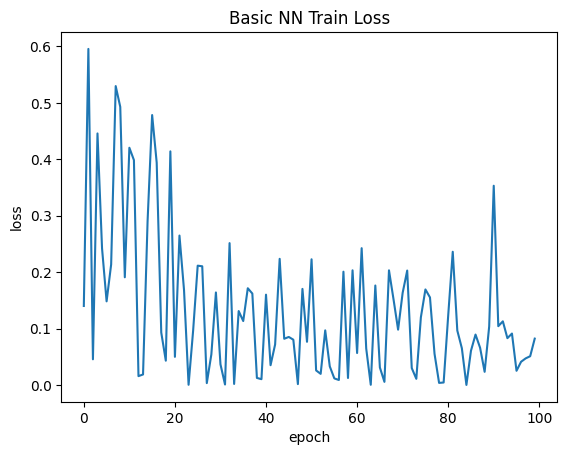

In [132]:
import matplotlib.pyplot as plt

plt.plot(range(len(losses)), losses)
plt.title("Basic NN Train Loss")
plt.ylabel("loss")
plt.xlabel("epoch")

In [133]:
def simple_linear(x):
    x = np.array(tokenize(x)) / total_tokens
    y = W @ x + B
    return np.clip(np.ceil(y*total_tokens), 0, total_tokens-1)[-1]

generate("날개는 돋았", simple_linear)

'날개는 돋았꼭업뜩켓온홍견팠면전븐쓱좇좇????????????????????????????????????????????????????????????????????????????????'

In [134]:
it = list(set("은쌉왕푼칠빗푼푼푼칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠칠"))
for char in it:
    print(stoi[char] / total_tokens) # 0.5를 출력하는 멍청이..

0.08782936010037641
0.16311166875784192
0.34127979924717694
0.2810539523212045
0.39397741530740277
0.6035131744040151


Text(0.5, 1.0, 'weight distribution')

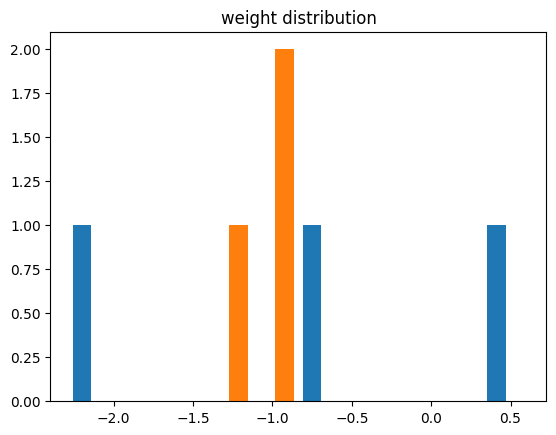

In [135]:
plt.hist(W1)
plt.title("weight distribution")

In [ ]:
W = np.random.randn(total_tokens, n) / 100
B = np.zeros((total_tokens))

for _ in range(1000):
    chunk = random.choice(chunks)
    ground_truth = tokenize(chunk)[n]
    x = np.array(tokenize(chunk)[:n]) / total_tokens
    print(f"{chunk[:n]} -> {chunk[n]}")

    y = W @ x + B
    exped = np.exp(y-y.max())
    softmaxed = exped / np.sum(exped, keepdims=False)
    # print(softmaxed)
    error = -np.log2(softmaxed[ground_truth])
    print("Error:", error, "Prediction:", itos[np.argmax(softmaxed)])
    losses.append(error)

    dydW = np.tile(x, (W.shape[0], 1)) 
    dydB = np.ones(B.shape[0])
    dydX = np.sum(W, axis=0)

    dEdy = softmaxed
    dEdy[ground_truth] -= 1
    dEdW = dEdy[:, None] * dydW
    dEdB = dEdy.copy()
    dEdX = W.T @ dEdy

    lr = 1e-1
    W -= lr * dEdW
    B -= lr * dEdB

그만_ -> 보
Error: 9.654359654113486 Prediction: 밴
_한다 -> .
Error: 9.651131236530587 Prediction: 보
술이_ -> 났
Error: 9.675195988492243 Prediction: 보
깊이_ -> 들
Error: 9.6316193288437 Prediction: 났
는_내 -> _
Error: 9.640398295364955 Prediction: .
_써늘 -> 하
Error: 9.624503646554171 Prediction: .
설사_ -> 와
Error: 9.646759151844895 Prediction: 보
그것은 -> _
Error: 9.406323226083018 Prediction: 하
느덧_ -> 오
Error: 9.639059179959574 Prediction: _
_도발 -> 적
Error: 9.628767331202452 Prediction: _
__그 -> 것
Error: 9.612972533612671 Prediction: _
_이런 -> _
Error: 9.077206141984794 Prediction: _
새,_ -> 뜨
Error: 9.648780062189417 Prediction: _
울해_ -> 하
Error: 9.31644976571266 Prediction: _
다._ -> 나
Error: 9.674160036535183 Prediction: _
에_외 -> 출
Error: 9.65801690752941 Prediction: _
._나 -> 는
Error: 9.647120756758474 Prediction: _
_누워 -> _
Error: 8.844073704070667 Prediction: _
떤_종 -> 류
Error: 9.638737390085057 Prediction: _
_그러 -> 나
Error: 9.343677391278222 Prediction: _
이_집 -> 으
Error: 9.653417855749531 Prediction

In [ ]:
def logistic(x):
    x = np.array(tokenize(x)) / total_tokens
    y = W @ x + B
    exped = np.exp(y-y.max())
    softmaxed = exped / np.sum(exped, keepdims=False)
    return np.argmax(softmaxed)

generate("날개는_돋았", logistic).replace(" ", "_")

'날개는_돋았______________________________________________________________________________________________'

In [146]:
emb_size = 10
Emb = np.random.randn(total_tokens, emb_size)
print(Emb[:2])
Emb[[1, 0, 1]]

[[ 0.02970286  0.48919849  0.90674236 -0.31576101 -1.04167382 -1.18143387
  -1.31191978 -0.40202356 -0.65590011  1.19113591]
 [-1.03475012  1.32370107 -0.80560645 -0.22259429  1.39900286 -1.91275453
   1.10168927 -0.30677326  0.34459843  1.52363338]]


array([[-1.03475012,  1.32370107, -0.80560645, -0.22259429,  1.39900286,
        -1.91275453,  1.10168927, -0.30677326,  0.34459843,  1.52363338],
       [ 0.02970286,  0.48919849,  0.90674236, -0.31576101, -1.04167382,
        -1.18143387, -1.31191978, -0.40202356, -0.65590011,  1.19113591],
       [-1.03475012,  1.32370107, -0.80560645, -0.22259429,  1.39900286,
        -1.91275453,  1.10168927, -0.30677326,  0.34459843,  1.52363338]])

In [ ]:
emb_size = 10
Emb = np.random.randn(total_tokens, emb_size)
W = np.random.randn(total_tokens, n) / 100
B = np.zeros((total_tokens))

for _ in range(1000):
    chunk = random.choice(chunks)
    ground_truth = tokenize(chunk)[n]
    indexs = tokenize(chunk)[:n]
    x = Emb[indexs]
    print(f"{chunk[:n]} -> {chunk[n]}")

    y = W @ x + B
    exped = np.exp(y-y.max())
    softmaxed = exped / np.sum(exped, keepdims=False)
    error = -np.log2(softmaxed[ground_truth])
    print("Error:", error, "Prediction:", itos[np.argmax(softmaxed)])
    losses.append(error)

    dydW = np.tile(x, (W.shape[0], 1)) 
    dydB = np.ones(B.shape[0])
    dydX = np.sum(W, axis=0)
    dXdEmb = np.zeros_like(Emb)
    dXdEmb[indexs] = 1

    dEdy = softmaxed
    dEdy[ground_truth] -= 1
    dEdW = dEdy[:, None] * dydW
    dEdB = dEdy.copy()
    dEdX = W.T @ dEdy
    dE

    lr = 1e-1
    W -= lr * dEdW
    B -= lr * dEdB